<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/statistics/index.html">Statistics</a><span class="sep">·</span>Part 2 · Comparing two samples</p><p class="mh-facts"><span class="lvl lvl-intermediate">Intermediate</span></p><p class="mh-assumes">Assumes <span class="unwritten" title="not written yet">Histograms, quantiles and QQ plots</span> and <span class="unwritten" title="not written yet">What a p-value is not</span>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

The two-sample Kolmogorov–Smirnov test compares two cumulative curves and reports their largest vertical gap, with no assumption about the shape of either distribution. Applied to two simulated vineyard blocks under different pruning regimes, it turns the cumulative yield curve growers already track into a hypothesis test on harvest timing. Afterwards you will be able to run `scipy.stats.ks_2samp` on harvest observations and judge how large a timing shift must be before it becomes detectable.
:::

Imagine two vineyard fields side by side: the same Shiraz variety, the same vine age, the same soil. The only difference is that one was **cane-pruned** in early winter and the other received **late spur pruning** in early spring to delay bud-break.

Both fields reach 100% of their seasonal yield by the end of harvest. But *how fast* do they get there each week, and is the timing difference statistically meaningful or seasonal noise?

The **Kolmogorov–Smirnov (K-S) test** answers exactly that without assuming any particular distribution shape. It compares the two **cumulative harvest curves** directly and measures their maximum divergence.

## Key concepts

### The ECDF as a cumulative yield curve

For a harvest season of $n$ weeks, we treat each week's yield percentage as a weight. The **empirical cumulative distribution function** (ECDF) at week $x$ is:

$$F(x) = \sum_{w=1}^{x} p_w$$

where $p_w$ is the fraction of total seasonal yield harvested in week $w$. This is the **cumulative yield curve** growers already track, reframed as a statistical tool.

### The D-statistic

The K-S test statistic is the **maximum absolute vertical distance** between the two cumulative yield curves:

$$D_{n,m} = \sup_x \left|F_{1,n}(x) - F_{2,m}(x)\right|$$

Intuitively: **at which week do the two fields diverge most in accumulated yield, and by how much?**

### The null hypothesis

> *The two fields harvest from the same underlying temporal distribution, i.e. pruning had no meaningful effect on harvest timing.*

A large D-statistic (small p-value) is evidence to **reject $H_0$** and conclude that the pruning strategies produced different harvest timing.

### Why K-S for harvest analysis

| Property | Why It Matters Here |
|---|---|
| **Distribution-agnostic** | Harvest curves don't follow a textbook distribution |
| **Sensitive to timing shifts** | Detects when one field consistently picks earlier |
| **Sensitive to spread changes** | Detects if one field's harvest is more concentrated |
| **Visual & intuitive** | The ECDF *is* the cumulative yield curve growers already use |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

rng = np.random.default_rng(42)

## Simulating two harvests

We simulate a **16-week harvest window** for two Shiraz fields:

| Field | Pruning Style | Expected Peak | Harvest Pattern |
|---|---|---|---|
| **Field A** | Cane pruning (early winter) | Week 5 | Earlier, concentrated |
| **Field B** | Late spur pruning (early spring) | Week 10 | Later, more spread out |

Weekly yield percentages are modelled as a noisy bell-shaped profile (realistic for most stone and berry fruits), normalised so each field's season sums to exactly 100%.

The K-S test is then run on the **underlying week-level observations**, where each harvested kilogram "votes" for the week it came from.

In [2]:
N_WEEKS = 16  # harvest window length
N_OBS = 300  # number of synthetic kg-observations per field (for K-S)
weeks = np.arange(1, N_WEEKS + 1)


def harvest_profile(peak_week: float, spread: float) -> np.ndarray:
    """Bell-shaped weekly yield profile, normalised to sum to 100%."""
    raw = np.exp(-0.5 * ((weeks - peak_week) / spread) ** 2)
    noise = rng.normal(0, 0.04 * raw.max(), size=N_WEEKS)
    raw = (raw + noise).clip(min=0)
    return 100.0 * raw / raw.sum()


# Weekly yield percentages
yield_a = harvest_profile(peak_week=5.0, spread=2.2)  # Field A — cane pruned
yield_b = harvest_profile(peak_week=10.0, spread=3.0)  # Field B — late spur pruned

# Draw kg-level observations weighted by each week's yield share
prob_a = yield_a / yield_a.sum()
prob_b = yield_b / yield_b.sum()
sample_a = rng.choice(weeks, size=N_OBS, p=prob_a).astype(float)
sample_b = rng.choice(weeks, size=N_OBS, p=prob_b).astype(float)
# Add a small jitter so ties don't collapse the ECDF steps
sample_a += rng.uniform(-0.45, 0.45, size=N_OBS)
sample_b += rng.uniform(-0.45, 0.45, size=N_OBS)

ks_stat, p_value = stats.ks_2samp(sample_a, sample_b)

print("Seasonal yield summary")
print(
    f"  Field A peak week : {weeks[yield_a.argmax()]}  ({yield_a.max():.1f}% of season)"
)
print(
    f"  Field B peak week : {weeks[yield_b.argmax()]}  ({yield_b.max():.1f}% of season)"
)
print()
print(f"K-S statistic (D)  : {ks_stat:.4f}")
print(f"p-value            : {p_value:.4e}")
print(f"Reject H₀?         : {'Yes ✓' if p_value < 0.05 else 'No ✗'}  (α = 0.05)")

Seasonal yield summary
  Field A peak week : 4  (17.4% of season)
  Field B peak week : 10  (13.1% of season)

K-S statistic (D)  : 0.6800
p-value            : 2.4284e-66
Reject H₀?         : Yes ✓  (α = 0.05)


## Visualising the K-S method

The dual-panel figure below shows:

**Left: cumulative yield curves (ECDF)**
* **Blue curve**: Field A (cane pruned), cumulative % yield by week
* **Red curve**: Field B (late spur pruned), cumulative % yield by week
* **Green dashed line**: week and magnitude of the D-statistic (maximum ECDF gap)

**Right: weekly yield profile**
* Bar chart of each field's weekly harvest percentage, the raw shape driving the ECDF

The longer the green segment on the left, the more the pruning strategies differ in *when* they deliver yield.

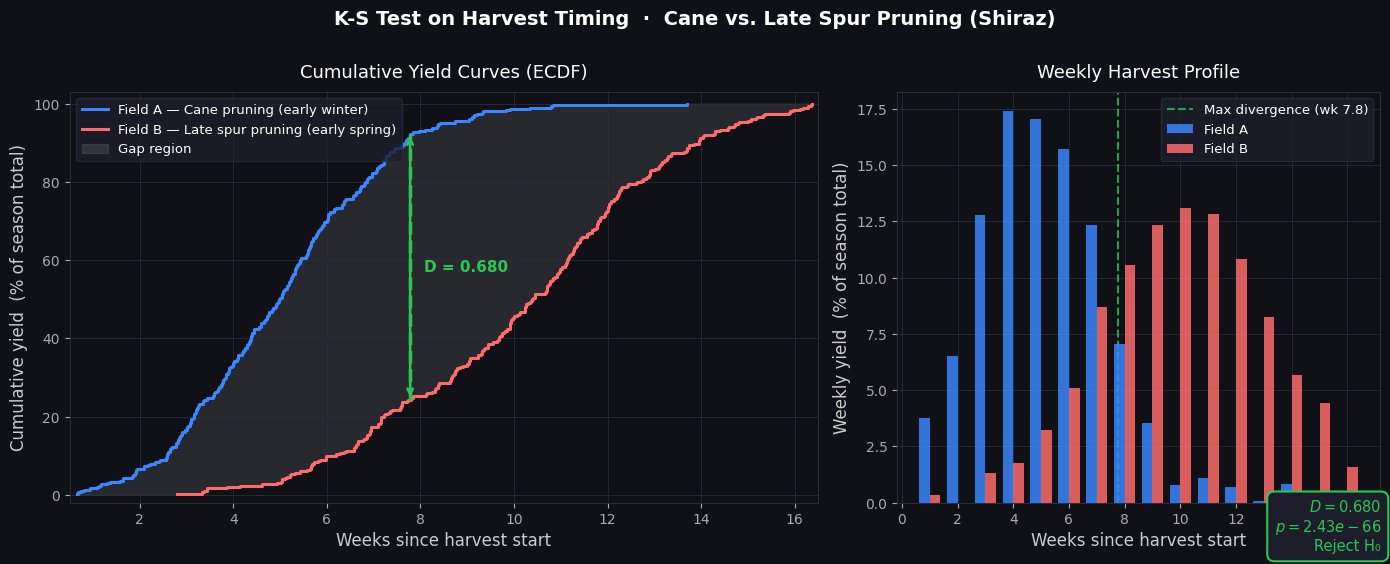

In [3]:
# ── Colour palette ────────────────────────────────────────────────
C1 = "#3A86FF"  # vivid blue  — Field A
C2 = "#FF6B6B"  # coral-red   — Field B
CG = "#2DC653"  # green       — D-statistic
BG = "#0F1117"  # dark background
GRID = "#2A2D3A"  # subtle grid


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors="#AAAAAA")
    ax.spines[:].set_color(GRID)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)


# ── Build ECDFs from samples ──────────────────────────────────────
def ecdf(data):
    xs = np.sort(data)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys


xa, ya = ecdf(sample_a)
xb, yb = ecdf(sample_b)

# Find the week of maximum ECDF gap
all_x = np.sort(np.concatenate([xa, xb]))
ecdf_a = np.searchsorted(xa, all_x, side="right") / N_OBS
ecdf_b = np.searchsorted(xb, all_x, side="right") / N_OBS
diffs = np.abs(ecdf_a - ecdf_b)
max_idx = np.argmax(diffs)
x_ks = all_x[max_idx]
y_ks_low = min(ecdf_a[max_idx], ecdf_b[max_idx])
y_ks_high = max(ecdf_a[max_idx], ecdf_b[max_idx])

# ── Figure layout ────────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    gridspec_kw={"width_ratios": [1.55, 1]},
    facecolor=BG,
)
fig.suptitle(
    "K-S Test on Harvest Timing  ·  Cane vs. Late Spur Pruning (Shiraz)",
    color="white",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

# ── LEFT: cumulative yield curves ────────────────────────────────
ax = axes[0]
style_ax(ax)

ax.step(
    xa,
    ya * 100,
    where="post",
    color=C1,
    lw=2.2,
    zorder=3,
    label="Field A — Cane pruning (early winter)",
)
ax.step(
    xb,
    yb * 100,
    where="post",
    color=C2,
    lw=2.2,
    zorder=3,
    label="Field B — Late spur pruning (early spring)",
)

# Shaded gap
ax.fill_between(
    all_x,
    ecdf_a * 100,
    ecdf_b * 100,
    alpha=0.10,
    color="white",
    zorder=1,
    label="Gap region",
)

# D-statistic annotation
ax.vlines(
    x_ks, y_ks_low * 100, y_ks_high * 100, color=CG, lw=2.5, linestyle="--", zorder=4
)
ax.annotate(
    "",
    xy=(x_ks, y_ks_high * 100),
    xytext=(x_ks, y_ks_low * 100),
    arrowprops=dict(arrowstyle="<->", color=CG, lw=1.8),
)
ax.text(
    x_ks + 0.3,
    (y_ks_low + y_ks_high) / 2 * 100,
    f"D = {ks_stat:.3f}",
    color=CG,
    fontsize=11,
    va="center",
    fontweight="bold",
)

ax.set_xlim(0.5, N_WEEKS + 0.5)
ax.set_ylim(-2, 103)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_xlabel("Weeks since harvest start", color="#CCCCCC", fontsize=12)
ax.set_ylabel("Cumulative yield  (% of season total)", color="#CCCCCC", fontsize=12)
ax.set_title("Cumulative Yield Curves (ECDF)", color="white", fontsize=13, pad=10)
ax.legend(
    facecolor="#1C1E2B",
    edgecolor=GRID,
    labelcolor="white",
    fontsize=9.5,
    loc="upper left",
)

# ── RIGHT: weekly yield bar chart ────────────────────────────────
ax2 = axes[1]
style_ax(ax2)

bar_w = 0.38
ax2.bar(
    weeks - bar_w / 2,
    yield_a,
    width=bar_w,
    color=C1,
    alpha=0.85,
    label="Field A",
    zorder=3,
)
ax2.bar(
    weeks + bar_w / 2,
    yield_b,
    width=bar_w,
    color=C2,
    alpha=0.85,
    label="Field B",
    zorder=3,
)
ax2.axvline(
    x_ks,
    color=CG,
    lw=1.5,
    linestyle="--",
    alpha=0.8,
    label=f"Max divergence (wk {x_ks:.1f})",
)

ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.set_xlabel("Weeks since harvest start", color="#CCCCCC", fontsize=12)
ax2.set_ylabel("Weekly yield  (% of season total)", color="#CCCCCC", fontsize=12)
ax2.set_title("Weekly Harvest Profile", color="white", fontsize=13, pad=10)
ax2.legend(
    facecolor="#1C1E2B",
    edgecolor=GRID,
    labelcolor="white",
    fontsize=9.5,
)

# ── Result badge ─────────────────────────────────────────────────
verdict = "Reject H\u2080" if p_value < 0.05 else "Fail to Reject H\u2080"
verdict_col = CG if p_value < 0.05 else C2
result_text = f"$D = {ks_stat:.3f}$\n$p = {p_value:.2e}$\n{verdict}"
fig.text(
    0.99,
    0.02,
    result_text,
    ha="right",
    va="bottom",
    color=verdict_col,
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="#1C1E2B", edgecolor=verdict_col, lw=1.5
    ),
)

plt.tight_layout()
plt.show()

### Reading the plot

| Element | Agronomic Meaning |
|---|---|
| **Blue cumulative curve** | By week X, Field A has harvested this % of its total season yield |
| **Red cumulative curve** | Same for Field B — shifted right (later peak) and shallower (more spread) |
| **Green dashed line** | The week where the two harvest strategies diverge most |
| **Shaded gap** | The overall "area of opportunity" — weeks where you'd pick differently depending on field |

A large D-statistic here means the pruning strategy had a **statistically significant effect on harvest timing**, not just season-to-season noise.

### Sensitivity to pruning delay

In practice you want to know *how many weeks of pruning delay are needed before the effect becomes statistically detectable*.

Below we sweep the peak-week offset of Field B from 0 (identical to Field A) to 8 weeks later, and track the K-S D-statistic and p-value.

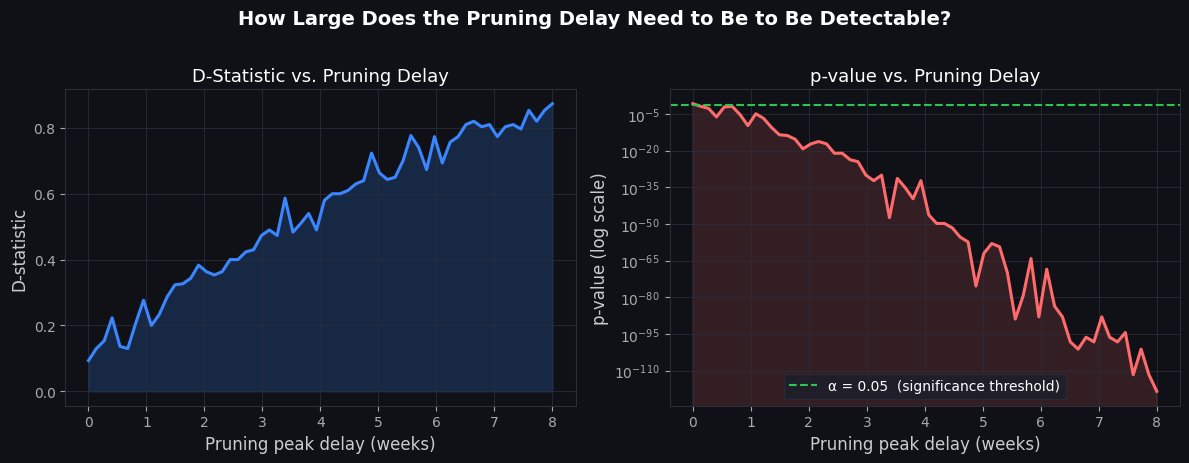

In [4]:
offsets = np.linspace(0, 8, 60)  # weeks of peak delay for Field B
d_stats, p_vals = [], []

for offset in offsets:
    ya_ = harvest_profile(peak_week=5.0, spread=2.2)
    yb_ = harvest_profile(peak_week=5.0 + offset, spread=3.0)
    pa_ = ya_ / ya_.sum()
    pb_ = yb_ / yb_.sum()
    sa = rng.choice(weeks, size=N_OBS, p=pa_).astype(float) + rng.uniform(
        -0.45, 0.45, N_OBS
    )
    sb = rng.choice(weeks, size=N_OBS, p=pb_).astype(float) + rng.uniform(
        -0.45, 0.45, N_OBS
    )
    d, p = stats.ks_2samp(sa, sb)
    d_stats.append(d)
    p_vals.append(p)

fig2, (ax_d, ax_p) = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=BG)

for ax in (ax_d, ax_p):
    style_ax(ax)

ax_d.plot(offsets, d_stats, color=C1, lw=2.2)
ax_d.fill_between(offsets, d_stats, alpha=0.2, color=C1)
ax_d.set_xlabel("Pruning peak delay (weeks)", color="#CCCCCC", fontsize=12)
ax_d.set_ylabel("D-statistic", color="#CCCCCC", fontsize=12)
ax_d.set_title("D-Statistic vs. Pruning Delay", color="white", fontsize=13)

ax_p.semilogy(offsets, p_vals, color=C2, lw=2.2)
ax_p.fill_between(offsets, p_vals, alpha=0.15, color=C2)
ax_p.axhline(
    0.05, color=CG, lw=1.5, linestyle="--", label="α = 0.05  (significance threshold)"
)
ax_p.set_xlabel("Pruning peak delay (weeks)", color="#CCCCCC", fontsize=12)
ax_p.set_ylabel("p-value (log scale)", color="#CCCCCC", fontsize=12)
ax_p.set_title("p-value vs. Pruning Delay", color="white", fontsize=13)
ax_p.legend(facecolor="#1C1E2B", edgecolor=GRID, labelcolor="white", fontsize=10)

fig2.suptitle(
    "How Large Does the Pruning Delay Need to Be to Be Detectable?",
    color="white",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

As the pruning-induced peak delay grows:

* The **D-statistic rises**: the cumulative yield curves diverge more.
* The **p-value drops** below the 0.05 threshold (green dashed line): the effect becomes statistically significant.

This lets a viticulturalist answer: *"With my field size and sampling capability, how different does my pruning timing need to be before I can attribute the harvest shift to pruning rather than seasonal noise?"*

### Practical usage with `scipy`

```python
from scipy import stats

# 2-sample K-S test on kg-level harvest observations
ks_stat, p_value = stats.ks_2samp(field_a_observations, field_b_observations)

# 1-sample: compare against a theoretical harvest model
ks_stat, p_value = stats.kstest(field_a_observations, cdf=my_theoretical_cdf)
```

Each observation can be the harvested week for an individual bin, picker tally or sensor record; the test works at any granularity.

## Key takeaways

- The ECDF of harvest week is the cumulative yield curve growers already track, so the K-S test needs no new data collection.
- The D-statistic is the largest vertical gap between two cumulative curves; its p-value is the probability of a gap that large if both fields harvested identically.
- The test makes no distributional assumption and is sensitive to both timing shifts and changes in spread.
- Sweeping the peak delay shows how large a pruning effect must be before it is detectable at a given field size and sampling rate.

| Concept | In This Context |
|---|---|
| **ECDF** | Cumulative % of total seasonal yield by harvest week |
| **D-statistic** | Maximum divergence between Field A and Field B's cumulative yield curves |
| **p-value** | Probability of seeing this gap if both fields truly harvest identically |
| **Reject $H_0$** | Pruning strategies produced **statistically different** harvest timing |
| **Strengths** | No distribution assumption; sensitive to both timing shifts and shape changes |

> **Tip:** The K-S test works best with continuous data. If yields are reported in coarse weekly bins, add small random jitter before testing to avoid ties inflating the D-statistic.

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-up" href="/series/statistics/index.html"><span>Series</span>Statistics</a></div>
<!-- CURRICULUM_FOOTER_END -->